#### Face verification system by Principal Component Analysis (PCA)

In [6]:
import scipy.io
data = scipy.io.loadmat('facedata.mat')
print(data['facedata'].shape)
print(data['facedata'][0,0])
print(data['facedata'][0,0].shape)

(40, 10)
[[48 46 50 ... 50 54 53]
 [47 47 48 ... 37 46 50]
 [46 48 43 ... 33 41 51]
 ...
 [49 49 50 ... 45 46 47]
 [48 48 49 ... 45 46 46]
 [51 48 50 ... 45 45 46]]
(56, 46)


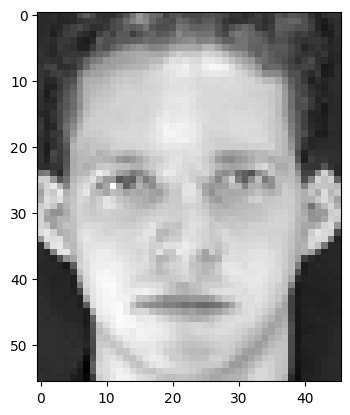

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
plt.imshow(data['facedata'][0,0],cmap="gray")
plt.show()

#### Working with images

Each pixel in an image is usually represented by a 8-bit unsigned integer (values from 0 to 255).
In order to easily work on images, we usually convert them to floats or doubles using the following
command.

In [10]:
from skimage import img_as_float
xf = {}
xf[0,0] = img_as_float(data['facedata'][0,0])
print(xf[0,0])

[[0.18823529 0.18039216 0.19607843 ... 0.19607843 0.21176471 0.20784314]
 [0.18431373 0.18431373 0.18823529 ... 0.14509804 0.18039216 0.19607843]
 [0.18039216 0.18823529 0.16862745 ... 0.12941176 0.16078431 0.2       ]
 ...
 [0.19215686 0.19215686 0.19607843 ... 0.17647059 0.18039216 0.18431373]
 [0.18823529 0.18823529 0.19215686 ... 0.17647059 0.18039216 0.18039216]
 [0.2        0.18823529 0.19607843 ... 0.17647059 0.17647059 0.18039216]]


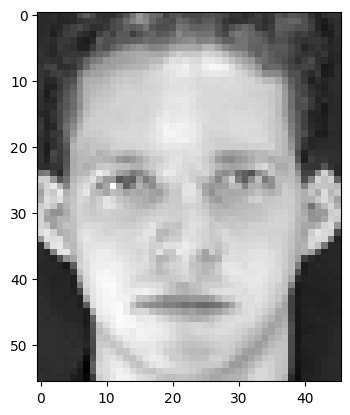

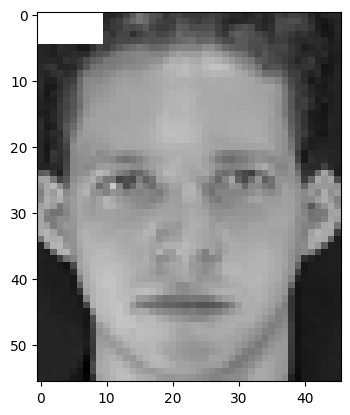

In [11]:
plt.imshow(xf[0,0],cmap="gray")
plt.show()
x_temp = xf[0,0].copy()
x_temp[0:5,0:10] = 1
# In float format, 1 is white
plt.imshow(x_temp,cmap="gray")
plt.show()

In [ ]:
import numpy as np

xf[0,1] = img_as_float(data['facedata'][0,1])
distance = np.linalg.norm(xf[0,0].flatten() - xf[0,1].flatten())
print(distance)

10.037616294165492


In [ ]:
import numpy as np

def compute_similarity_matrix(T, D):
    """
    Compute similarity matrix A where A[i,j] is the Euclidean distance
    between data sample i from list T and data sample j from list D.
    
    Parameters:
    T: List or array of data samples (shape: n_samples_T x features)
    D: List or array of data samples (shape: n_samples_D x features)
    
    Returns:
    A: Similarity matrix (shape: len(T) x len(D))
    """
    n_T = len(T)
    n_D = len(D)
    A = np.zeros((n_T, n_D))
    
    for i in range(n_T):
        for j in range(n_D):
            # Flatten samples and compute Euclidean distance
            A[i, j] = np.linalg.norm(T[i].flatten() - D[j].flatten())
    
    return A

[[ 0.         10.03761629]
 [10.03761629  0.        ]]


Similarity matrix shape: (120, 280)
Training set size (T): 120
Testing set size (D): 280


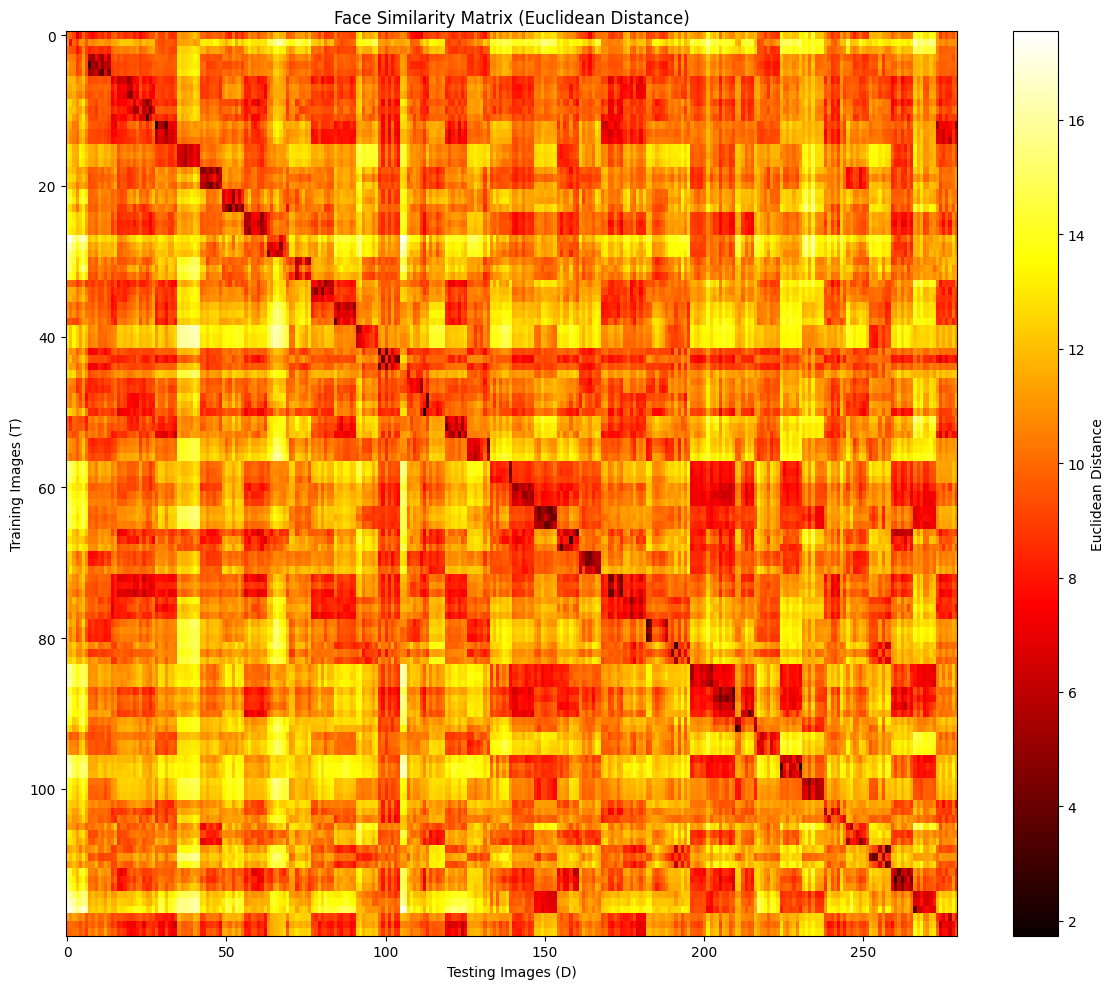

In [18]:
# Load all images into xf dictionary
for person in range(40):
    for image in range(10):
        xf[person, image] = img_as_float(data['facedata'][person, image])

# Build training set T (first 3 images from each of 40 people)
T = []
for person in range(40):
    for image in range(3):
        T.append(xf[person, image])

# Build testing set D (images 3-9 from each of 40 people)
D = []
for person in range(40):
    for image in range(3, 10):
        D.append(xf[person, image])

# Compute similarity matrix A
A = compute_similarity_matrix(T, D)

print("Similarity matrix shape:", A.shape)
print("Training set size (T):", len(T))
print("Testing set size (D):", len(D))

# Visualize the similarity matrix as an image
plt.figure(figsize=(12, 10))
plt.imshow(A, cmap='hot', aspect='auto')
plt.colorbar(label='Euclidean Distance')
plt.xlabel('Testing Images (D)')
plt.ylabel('Training Images (T)')
plt.title('Face Similarity Matrix (Euclidean Distance)')
plt.tight_layout()
plt.show()

In [19]:
def compute_verification_rates(A, threshold):
    """
    Compute true positive rate and false alarm rate for face verification.
    
    Parameters:
    A: Similarity matrix (shape: 120 x 280) where A[i,j] is Euclidean distance
       between training image i and testing image j
    threshold: Distance threshold t for verification decision
    
    Returns:
    tpr: True positive rate (correctly identified faces from same person)
    far: False alarm rate (incorrectly identified faces from different person)
    """
    true_positives = 0
    false_alarms = 0
    total_genuine = 0
    total_impostor = 0
    
    # For each training image (person p, image i in range 0-2)
    for train_idx in range(120):
        person_train = train_idx // 3  # Which person (0-39)
        
        # For each testing image (person q, image j in range 3-9)
        for test_idx in range(280):
            person_test = test_idx // 7  # Which person (0-39)
            
            distance = A[train_idx, test_idx]
            
            if person_train == person_test:
                # Genuine comparison (same person)
                total_genuine += 1
                if distance < threshold:
                    true_positives += 1
            else:
                # Impostor comparison (different person)
                total_impostor += 1
                if distance < threshold:
                    false_alarms += 1
    
    # Compute rates
    tpr = true_positives / total_genuine if total_genuine > 0 else 0
    far = false_alarms / total_impostor if total_impostor > 0 else 0
    
    return tpr, far

# Compute verification rates for threshold t = 10
threshold = 10
tpr, far = compute_verification_rates(A, threshold)

print(f"Threshold t = {threshold}")
print(f"True Positive Rate (TPR): {tpr:.4f}")
print(f"False Alarm Rate (FAR): {far:.4f}")
print(f"True Positives: {tpr * (120 * 7 * 40):.0f} out of {120 * 7 * 40}")
print(f"False Alarms: {far * (120 * 3 * 40 * 39):.0f} out of {120 * 3 * 40 * 39}")

Threshold t = 10
True Positive Rate (TPR): 0.9714
False Alarm Rate (FAR): 0.3547
True Positives: 32640 out of 33600
False Alarms: 199217 out of 561600


Minimum threshold: 1.7420
Maximum threshold: 17.5417


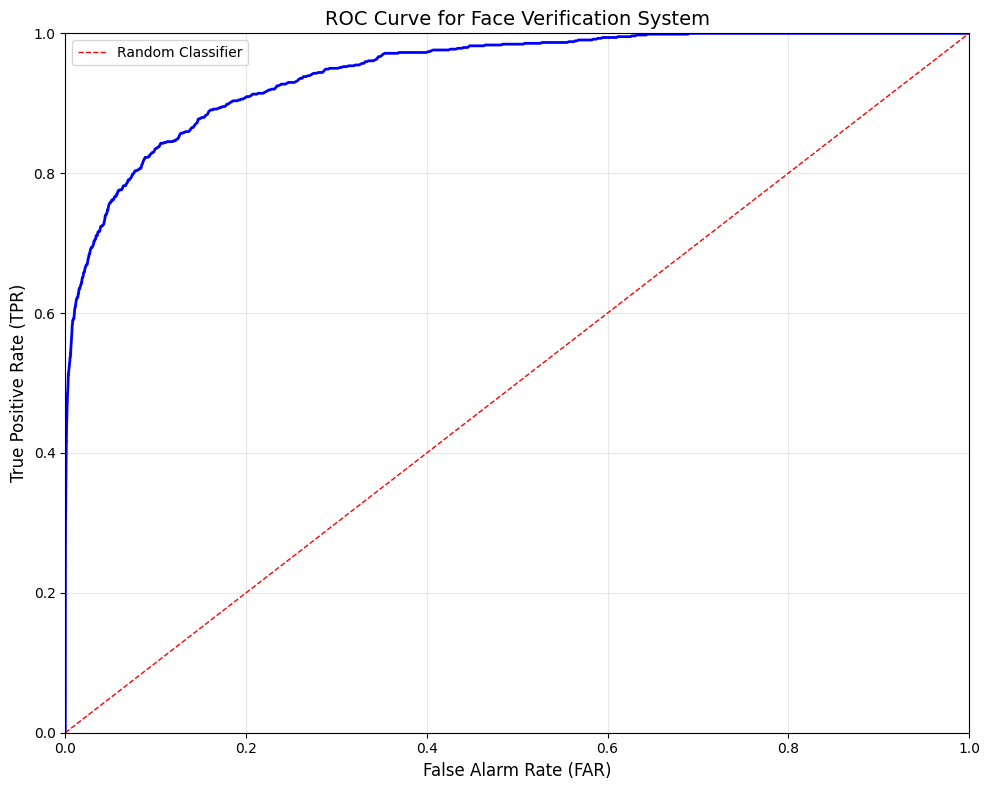


ROC Curve Statistics:
Number of thresholds tested: 2000
Threshold range: [1.7420, 17.5417]
Best TPR achieved: 1.0000
FAR at best TPR: 0.6906


In [21]:
def plot_roc_curve(A, num_thresholds=1000):
    """
    Generate and plot the ROC curve for face verification system.
    
    Parameters:
    A: Similarity matrix (shape: 120 x 280) where A[i,j] is Euclidean distance
    num_thresholds: Number of threshold levels to test (default: 1000)
    
    Returns:
    None (displays plot)
    """
    # Find min and max distances in the similarity matrix
    min_threshold = np.min(A)
    max_threshold = np.max(A)
    
    print(f"Minimum threshold: {min_threshold:.4f}")
    print(f"Maximum threshold: {max_threshold:.4f}")
    
    # Generate equally spaced thresholds
    thresholds = np.linspace(min_threshold, max_threshold, num_thresholds)
    
    # Store TPR and FAR for each threshold
    tpr_list = []
    far_list = []
    
    # Compute verification rates for each threshold
    for threshold in thresholds:
        tpr, far = compute_verification_rates(A, threshold)
        tpr_list.append(tpr)
        far_list.append(far)
    
    # Plot ROC curve
    plt.figure(figsize=(10, 8))
    plt.plot(far_list, tpr_list, 'b-', linewidth=2)
    plt.xlabel('False Alarm Rate (FAR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title('ROC Curve for Face Verification System', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    
    # Add diagonal reference line (random classifier)
    plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
    plt.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print some key statistics
    print(f"\nROC Curve Statistics:")
    print(f"Number of thresholds tested: {num_thresholds}")
    print(f"Threshold range: [{min_threshold:.4f}, {max_threshold:.4f}]")
    print(f"Best TPR achieved: {max(tpr_list):.4f}")
    print(f"FAR at best TPR: {far_list[np.argmax(tpr_list)]:.4f}")

# Generate and plot ROC curve with 1000 threshold levels
plot_roc_curve(A, num_thresholds=2000)